# PHẦN 1: ĐỒ ÁN 2 - DATA FITTING VÀ PHƯƠNG PHÁP OLS FROM SCRATCH
**Môn học:** Toán Ứng Dụng và Thống Kê (MTH00051)

Notebook này đóng vai trò là **Theoretical Demo**, tổng hợp và minh họa thực nghiệm các thuật toán được cài đặt hoàn toàn từ đầu không sử dụng các thư viện tính toán ma trận thông dụng như `numpy` hay `scipy`.

### Nội dung thực nghiệm:
1. Thực hiện hồi quy bình phương tối thiểu (OLS Fit) và phân tích các chỉ số đánh giá.
2. Kiểm chứng các tính chất toán học của ma trận Hat.
3. Trace nghiệm chính quy hóa Ridge và Lasso khi thay đổi hệ số phạt $\lambda$.
4. Vẽ 4 biểu đồ chẩn đoán phần dư.
5. Mô phỏng Monte Carlo kiểm chứng định lý Gauss-Markov.
6. Đánh giá độ ổn định bằng K-Fold Cross Validation.

In [2]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np # Chỉ dùng tạo dữ liệu test hoặc so sánh đối chứng ở phần CV

# Import các hàm core tự viết từ các file .py trong cùng thư mục
from ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference, vif, column_stack, create_ones
from ridge_lasso import ridge_fit, lasso_fit, plot_regularization_trace
from residual_analysis import task_7_residual_analysis, task_9_monte_carlo
from cross_validation import kfold_cv, compare_models_cv

## 1. Khởi tạo dữ liệu giả lập
Để kiểm chứng các hàm tính toán, ta tạo một tập dữ liệu giả lập gồm $n = 100$ mẫu, $p = 2$ biến dự báo dựa trên hàm tuyến tính gốc có nhiễu:
$$y = 2.5 + 1.2x_1 - 3.4x_2 + \epsilon \quad \text{với } \epsilon \sim \mathcal{N}(0, 0.5^2)$$

In [3]:
# Thiết lập seed để kết quả đồng nhất
random.seed(42)
np.random.seed(42)

n = 100
# Tạo ma trận đặc trưng gốc (chưa có intercept) dạng list of lists
X_raw = [[random.gauss(0, 1), random.gauss(2, 1)] for _ in range(n)]

# Tạo vector kết quả y có nhiễu
true_beta = [2.5, 1.2, -3.4]
y = []
for row in X_raw:
    epsilon = random.gauss(0, 0.5)
    yi = true_beta[0] + true_beta[1]*row[0] + true_beta[2]*row[1] + epsilon
    y.append(yi)

# Thêm cột 1 vào đầu ma trận để làm Intercept
X_design = column_stack(create_ones(n), X_raw)

print(f"Kích thước ma trận X_design: {len(X_design)}x{len(X_design[0])}")
print(f"Kích thước vector y: {len(y)}")
print("Mẫu 3 dòng đầu tiên của X_design:", X_design[:3])

Kích thước ma trận X_design: 100x3
Kích thước vector y: 100
Mẫu 3 dòng đầu tiên của X_design: [[1.0, -0.14409032957792836, 1.8270963996684806], [1.0, -0.11131586156766246, 2.701983725098863], [1.0, -0.12758828378288709, 0.5026465856590425]]


## 2. Ước lượng OLS và suy luận thống kê
Ta tiến hành giải phương trình chuẩn:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$
Sau đó tính toán sai số chuẩn (SE), trị thống kê $t$, $p$-value và khoảng tin cậy $95\%$.

In [7]:
# 1. Chạy OLS Fit để lấy beta_hat và sigma2
ols_results = ols_fit(X_design, y)
beta_hat = ols_results["beta_hat"]
sigma2 = ols_results["sigma2"]

# 2. Tính các chỉ số mô hình
metrics = model_metrics(y, ols_results["y_hat"], p=2)

# 3. Tính suy luận thống kê cho hệ số
inference = coef_inference(X_design, y, beta_hat, sigma2, alpha=0.05)

# Hiển thị kết quả ước lượng hệ số
print("="*80)
print(f"{'Hệ số':<10}{'Giá trị ước lượng':<20}{'Sai số chuẩn (SE)':<18}{'t-statistic':<15}{'p-value':<10}")
text = "-"*80
print(text)
for j in range(len(beta_hat)):
    print(f"beta_{j:<5}{beta_hat[j]:<20.4f}{inference['se'][j]:<18.4f}{inference['t_stats'][j]:<15.4f}{inference['p_values'][j]:<10.4e}")
print("="*80)

# Hiển thị chỉ số tổng quan của mô hình
print(f"Số lượng mẫu (n): {metrics['n']}")
print(f"Hệ số xác định R²: {metrics['r2']:.4f}")
print(f"Hệ số R² hiệu chỉnh: {metrics['r2_adj']:.4f}")
print(f"Trị thống kê F: {metrics['f_stat']:.4f} (p-value: {metrics['f_pvalue']:.4e})")

Hệ số     Giá trị ước lượng   Sai số chuẩn (SE) t-statistic    p-value   
--------------------------------------------------------------------------------
beta_0    2.6500              0.1443            18.3636        0.0000e+00
beta_1    1.1591              0.0618            18.7585        0.0000e+00
beta_2    -3.4615             0.0630            -54.9814       0.0000e+00
Số lượng mẫu (n): 100
Hệ số xác định R²: 0.9735
Hệ số R² hiệu chỉnh: 0.9730
Trị thống kê F: 1782.6516 (p-value: 0.0000e+00)


## 3. Kiểm chứng các tính chất của ma trận Hat ($H$)
Ma trận Hat được định nghĩa: $H = X(X^T X)^{-1}X^T$. Theo lý thuyết toán học, ma trận này bắt buộc phải thỏa mãn 3 tính chất:
1. **Idempotent (Chiếu):** $H^2 = H$
2. **Symmetric (Đối xứng):** $H^T = H$
3. **Trace:** $\text{tr}(H) = \text{rank}(X) = p + 1$

In [10]:
# 1. Lấy kích thước ma trận Hat
n_samples = len(H)

# 2. Tính tính chất Trace: Tổng đường chéo chính của H
trace_H = sum(H[i][i] for i in range(n_samples))

# 3. Tính độ lệch đối xứng: Max absolute difference giữa H và H^T
max_sym_diff = 0.0
for i in range(n_samples):
    for j in range(n_samples):
        diff = abs(H[i][j] - H[j][i])
        if diff > max_sym_diff:
            max_sym_diff = diff

# 4. Tính độ lệch Idempotent: Nhân H x H và so sánh với H
H2 = [[sum(H[i][k] * H[k][j] for k in range(n_samples)) for j in range(n_samples)] for i in range(n_samples)]
max_idem_diff = 0.0
for i in range(n_samples):
    for j in range(n_samples):
        diff = abs(H2[i][j] - H[i][j])
        if diff > max_idem_diff:
            max_idem_diff = diff

# --- IN KẾT QUẢ ĐỊNH LƯỢNG ---
print("  XÁC MINH SỐ LIỆU TÍNH CHẤT MA TRẬN HAT (H) ")
print(f"1. Tính chất TRACE (Vết ma trận):")
print(f"   - Kỳ vọng (p + 1)        : {len(X_design[0])}")
print(f"   - Thực tế tính toán      : {trace_H:.4f} (Làm tròn: {round(trace_H)})")
print(f"2. Tính chất ĐỐI XỨNG (Symmetric):")
print(f"   - Sai số đối xứng lớn nhất: {max_sym_diff:.4e} (Tiến về 0)")
print(f"3. Tính chất CHIẾU (Idempotent - H² = H):")
print(f"   - Sai số lệch lớn nhất   : {max_idem_diff:.4e} (Tiến về 0)")

  XÁC MINH SỐ LIỆU TÍNH CHẤT MA TRẬN HAT (H) 
1. Tính chất TRACE (Vết ma trận):
   - Kỳ vọng (p + 1)        : 3
   - Thực tế tính toán      : 3.0000 (Làm tròn: 3)
2. Tính chất ĐỐI XỨNG (Symmetric):
   - Sai số đối xứng lớn nhất: 4.8572e-17 (Tiến về 0)
3. Tính chất CHIẾU (Idempotent - H² = H):
   - Sai số lệch lớn nhất   : 2.7756e-16 (Tiến về 0)


## 4. Kiểm tra đa cộng tuyến qua hệ số VIF
Hệ số phóng đại phương sai giúp nhận diện các biến dự báo có bị phụ thuộc tuyến tính lẫn nhau hay không:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

In [12]:
vif_vals = vif(X_design)
for idx, v in enumerate(vif_vals):
    print(f"VIF của biến đặc trưng {idx + 1}: {v:.4f} {'(Bình thường)' if v < 10 else '(Đa cộng tuyến nghiêm trọng!)'}")

VIF của biến đặc trưng 1: 1.0066 (Bình thường)
VIF của biến đặc trưng 2: 1.0066 (Bình thường)


## 5. Minh họa Ridge & Lasso Traces
Ta tiến hành quét một dải các giá trị $\lambda$ (từ $10^{-3}$ đến $10^3$) để xem sự thay đổi của các hệ số hồi quy chuẩn hóa (`beta_std`) qua đồ thị đường cong Regularization Trace.

1. Đồ thị hệ số của hồi quy Ridge:


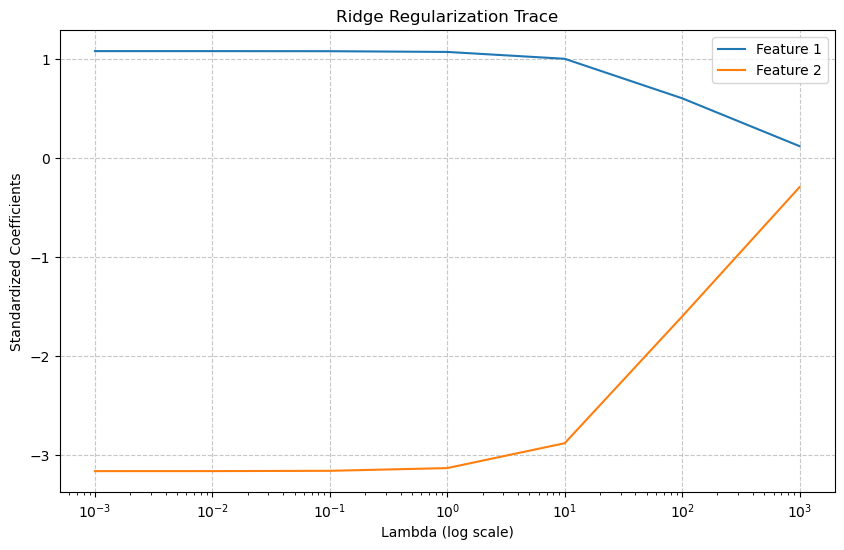

2. Đồ thị hệ số của hồi quy Lasso (Coordinate Descent):


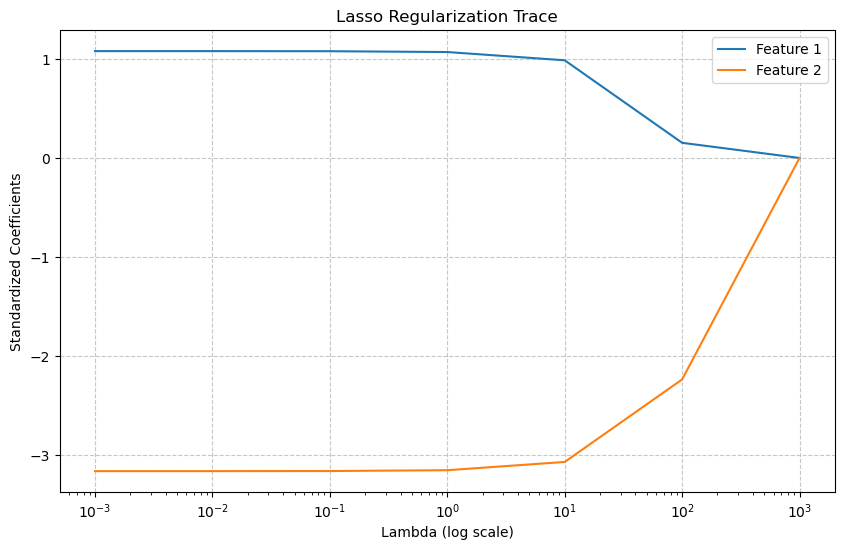

In [13]:
lambdas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

print("1. Đồ thị hệ số của hồi quy Ridge:")
plot_regularization_trace(X_design, y, lambdas, method='ridge')

print("2. Đồ thị hệ số của hồi quy Lasso (Coordinate Descent):")
plot_regularization_trace(X_design, y, lambdas, method='lasso')

## 6. Phân tích và chẩn đoán mô hình qua phần dư (Residual Analysis)
Để đảm bảo các giả định của mô hình hồi quy tuyến tính cổ điển được thỏa mãn, ta tiến hành vẽ 4 biểu đồ chẩn đoán cốt lõi:
1. **Residuals vs Fitted:** Kiểm tra tính tuyến tính và phương sai sai số không đổi.
2. **Normal Q-Q:** Kiểm tra giả định phần dư tuân theo phân phối chuẩn.
3. **Scale-Location:** Kiểm tra xu hướng thay đổi độ lớn phần dư theo giá trị dự báo.
4. **Residuals vs Leverage:** Phát hiện các điểm dữ liệu có sức ảnh hưởng quá lớn.

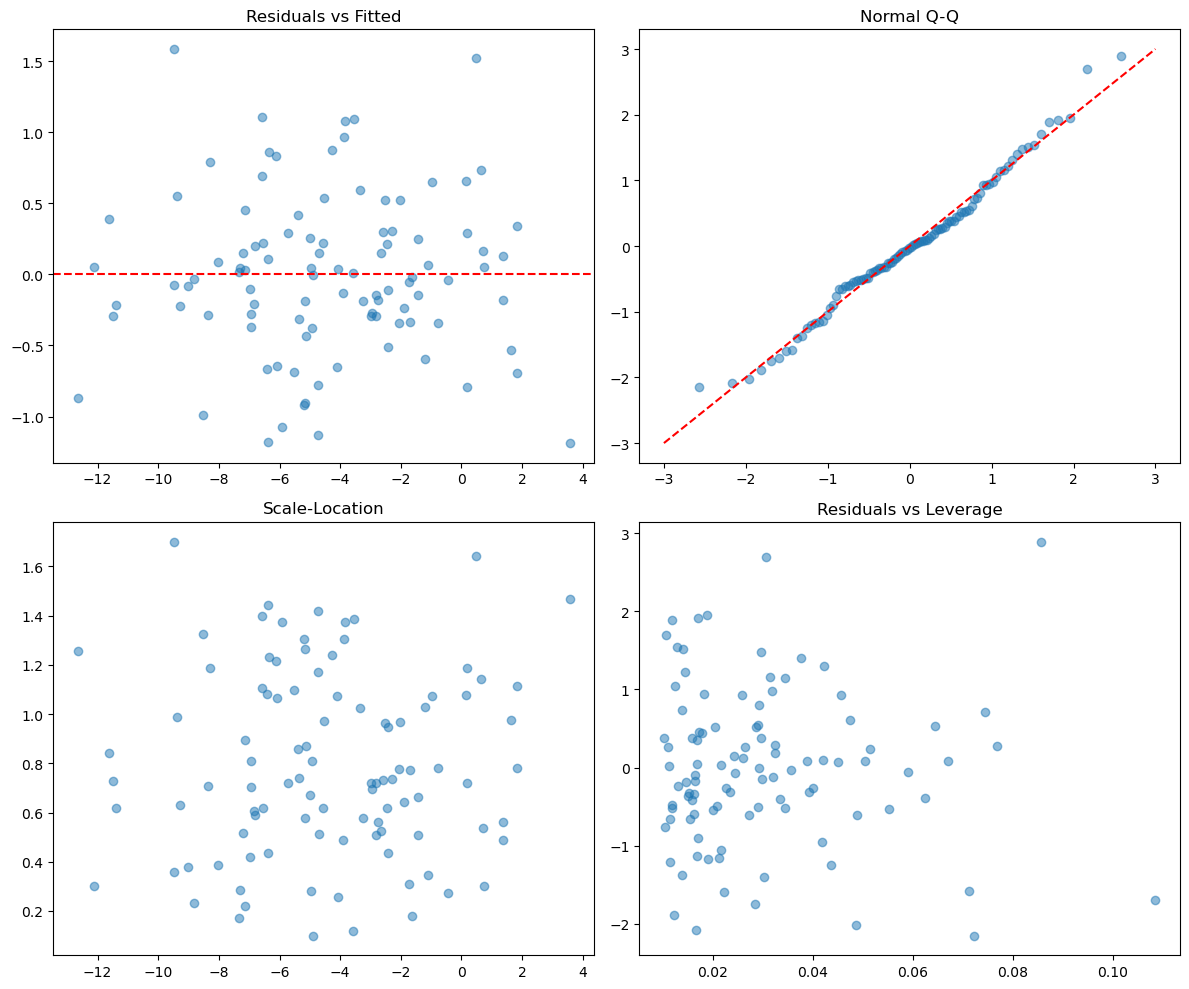

In [14]:
task_7_residual_analysis(X_design, y, beta_hat)

## 7. Mô phỏng Monte Carlo minh họa định lý Gauss-Markov
Định lý Gauss-Markov phát biểu rằng trong các ước lượng tuyến tính không chệch, ước lượng OLS là ước lượng hiệu quả nhất (Best Linear Unbiased Estimator - BLUE) - tức là có phương sai nhỏ nhất. 

Ta chạy mô phỏng lặp lại $1000$ lần để dựng phân phối thực nghiệm của $\hat{\beta}_1$.

--- Kết quả Monte Carlo ---
Beta_1 thật: 2.5
E[Beta_1_hat]: 2.4997


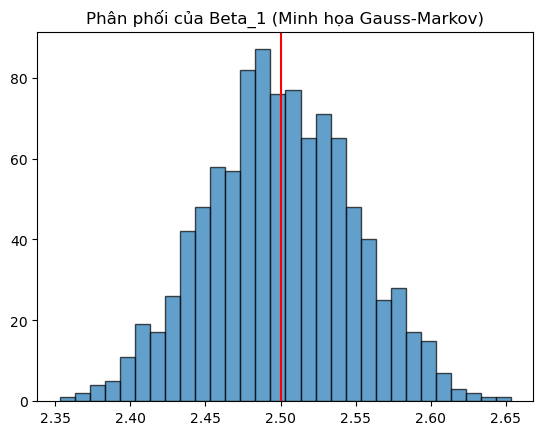

In [15]:
task_9_monte_carlo(n_sim=1000)

## 8. Đánh giá mô hình bằng K-Fold Cross Validation
Cuối cùng, ta thực hiện chia tập dữ liệu thành $K = 5$ phần (folds) để đánh giá khả năng tổng quát hóa của thuật toán, tránh việc chỉ đánh giá trên tập huấn luyện cố định.

In [16]:
# Đưa dữ liệu về dạng numpy array để khớp với cấu trúc nhận diện của file cross_validation.py
X_np = np.array(X_design)
y_np = np.array(y)

print("--- Đang thực hiện 5-Fold Cross Validation cho mô hình OLS ---")
cv_score, mse_list = kfold_cv(X_np, y_np, k=5, seed=42)

print(f"Danh sách MSE qua 5 Folds: {[round(m, 5) for m in mse_list]}")
print(f"Điểm đánh giá CV Score trung bình (MSE): {cv_score:.5f}")

# Thử so sánh các hàm fit khác nhau nếu cần thiết bằng hàm compare_models_cv
print("\n--- Thực hiện so sánh mô hình (Ví dụ so sánh mô hình) ---")
def dummy_ols_model(X_tr, y_tr):
    XtX = X_tr.T @ X_tr
    Xty = X_tr.T @ y_tr
    return np.linalg.solve(XtX, Xty)

compare_models_cv(X_np, y_np, model_fns=[dummy_ols_model], model_names=["Custom OLS Base"], k=5)

--- Đang thực hiện 5-Fold Cross Validation cho mô hình OLS ---
Danh sách MSE qua 5 Folds: [np.float64(0.26947), np.float64(0.31057), np.float64(0.27533), np.float64(0.38759), np.float64(0.43365)]
Điểm đánh giá CV Score trung bình (MSE): 0.33532

--- Thực hiện so sánh mô hình (Ví dụ so sánh mô hình) ---
  Custom OLS Base      | CV Score (MSE): 0.335322

 Mô hình tốt nhât: Custom OLS Base (MSE = 0.335322)


{'Custom OLS Base': np.float64(0.3353222325111685)}